<a href="https://colab.research.google.com/github/mar25-iia2-radiographies/02_modelisation/blob/main/02_radiographie_covid_classification_Dense_TF_Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification radiographies COVID-19 — Baseline Dense Clahe_True

Ce notebook constitue le **modèle témoin / référence** de la future série :
1. **Baseline Dense** (ce notebook)
2. **CNN custom**
3. **Transfer learning** (VGG / ResNet / EfficientNet, etc.)

L'objectif ici n'est **pas** de faire le meilleur modèle possible, mais de construire une **référence propre, stable et bien commentée** pour comparer les architectures plus avancées.

## Choix de continuité avec les notebooks précédents
- Même dataset Kaggle : `tawsifurrahman/covid19-radiography-database`
- Même logique de classes : **COVID / Normal / Lung_Opacity / Viral Pneumonia**
- Même philosophie de prétraitement :
  - niveaux de gris (**grayscale**)
  - **masque pulmonaire** appliqué
  - **resize 128x128**
  - **normalisation [0,1]**
  - **CLAHE** conservé ici pour rester cohérent avec les anciens notebooks en MACHINE LEARNING, mais il restera **facile à désactiver** dans les expériences suivantes

## Pourquoi 128x128 et pas 224x224 ?
Pour un modèle **Dense**, on commence par un **Flatten**.  
Si on passe trop tôt à 224x224, le nombre de paramètres explose très vite.

## Pourquoi ce modèle est utile ?
Parce qu'il servira de **point de comparaison** :
- si le CNN fait à peine mieux, il y a un souci dans le pipeline
- si le CNN / transfer learning fait clairement mieux, on aura une comparaison propre

In [1]:

# =========================
# Installation (Colab)
# =========================
# TensorFlow est normalement déjà disponible dans Google Colab.
# On installe ici uniquement les bibliothèques utiles autour du pipeline.
!pip -q install kagglehub opencv-python scikit-learn seaborn

In [ ]:

# =========================
# Imports et environnement
# =========================
import os
import gc
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks

import kagglehub

print("TensorFlow version :", tf.__version__)
print("Keras version      :", keras.__version__)

# Vérification GPU
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    print("GPU détecté :", gpus)
else:
    print("Aucun GPU détecté. Le notebook fonctionnera quand même, mais plus lentement.")

# Pour une meilleure reproductibilité
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow version : 2.20.0
Keras version      : 3.13.2
GPU détecté : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:

# =========================
# Configuration générale
# =========================
# Cette cellule centralise les choix importants.
# Cela facilitera la transition vers le CNN puis le transfert learning.

# Taille d'entrée retenue pour le baseline Dense
TARGET_SIZE = 128

# 1 canal : niveaux de gris
N_CHANNELS = 1

# Prétraitement
APPLY_MASK = True
APPLY_CLAHE = True   # Conserver la continuité avec les anciens notebooks Machine Learning
CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_SIZE = (8, 8)

# Classes (même ordre logique que dans les anciens notebooks)
CATEGORIES = ["COVID", "Normal", "Lung_Opacity", "Viral Pneumonia"]
NUM_CLASSES = len(CATEGORIES)

# Entraînement
BATCH_SIZE = 32
EPOCHS = 25
LEARNING_RATE = 1e-3

# Architecture Dense de référence
DENSE_UNITS_1 = 256
DENSE_UNITS_2 = 64
DROPOUT_1 = 0.40
DROPOUT_2 = 0.30
L2_REG = 1e-4

print("Configuration chargée.")
print(f"Image d'entrée : {TARGET_SIZE}x{TARGET_SIZE}x{N_CHANNELS}")
print(f"CLAHE activé   : {APPLY_CLAHE}")
print(f"Masque activé  : {APPLY_MASK}")
print(f"Classes        : {CATEGORIES}")

Configuration chargée.
Image d'entrée : 128x128x1
CLAHE activé   : True
Masque activé  : True
Classes        : ['COVID', 'Normal', 'Lung_Opacity', 'Viral Pneumonia']


## Remarque importante pour les notebooks suivants

Ce notebook est volontairement construit de façon à faciliter la suite :
- pour le **CNN custom**, on pourra **réutiliser le même pipeline de données**
- pour le **transfer learning**, on adaptera surtout :
  - le nombre de canaux (**RGB au lieu de grayscale**)
  - la taille d'entrée (**souvent 224x224**)
  - le prétraitement spécifique du backbone choisi

Autrement dit : ce notebook est une bonne **base commune**.

In [4]:

# =========================
# Téléchargement du dataset Kaggle
# =========================
# On utilise kagglehub comme dans les notebooks récents.
data_path = Path(kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database"))
print("Dataset téléchargé / localisé dans :", data_path)

Using Colab cache for faster access to the 'covid19-radiography-database' dataset.
Dataset téléchargé / localisé dans : /kaggle/input/covid19-radiography-database


In [5]:

# =========================
# Construction des chemins images / masques
# =========================
# Chaque classe possède généralement deux sous-dossiers :
# - images
# - masks

image_paths = {}

for category in CATEGORIES:
    image_paths[f"{category}_images"] = data_path / category / "images"
    image_paths[f"{category}_masks"] = data_path / category / "masks"

for key, value in image_paths.items():
    print(f"{key}: {value}")

COVID_images: /kaggle/input/covid19-radiography-database/COVID/images
COVID_masks: /kaggle/input/covid19-radiography-database/COVID/masks
Normal_images: /kaggle/input/covid19-radiography-database/Normal/images
Normal_masks: /kaggle/input/covid19-radiography-database/Normal/masks
Lung_Opacity_images: /kaggle/input/covid19-radiography-database/Lung_Opacity/images
Lung_Opacity_masks: /kaggle/input/covid19-radiography-database/Lung_Opacity/masks
Viral Pneumonia_images: /kaggle/input/covid19-radiography-database/Viral Pneumonia/images
Viral Pneumonia_masks: /kaggle/input/covid19-radiography-database/Viral Pneumonia/masks


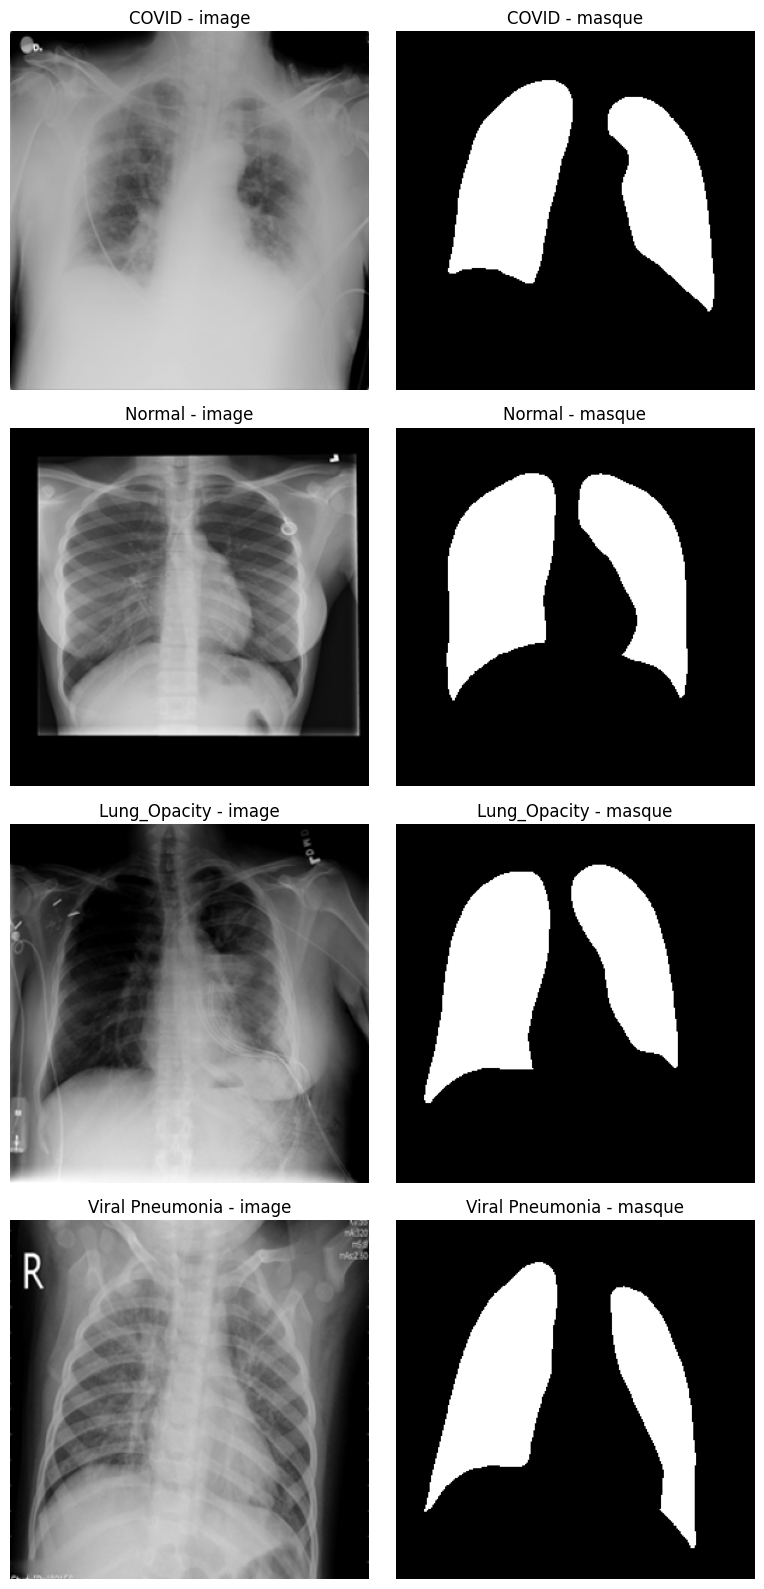

In [7]:

# =========================
# Vérification rapide visuelle
# =========================
# On affiche 1 image + 1 masque par classe pour vérifier que les chemins sont bons
# et que la structure du dataset correspond bien à ce qui est attendu.

fig, axes = plt.subplots(len(CATEGORIES), 2, figsize=(8, 4 * len(CATEGORIES)))

for i, category in enumerate(CATEGORIES):
    # Corrected paths to account for the extra subdirectory in the dataset
    img_dir = data_path / "COVID-19_Radiography_Dataset" / category / "images"
    mask_dir = data_path / "COVID-19_Radiography_Dataset" / category / "masks"

    img_files = sorted([p for p in img_dir.iterdir() if p.suffix.lower() in [".png", ".jpg", ".jpeg"]])
    if len(img_files) == 0:
        axes[i, 0].set_title(f"{category} - aucune image")
        axes[i, 0].axis("off")
        axes[i, 1].axis("off")
        continue

    img_path = img_files[0]
    mask_path = mask_dir / img_path.name

    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE) if mask_path.exists() else None

    axes[i, 0].imshow(img, cmap="gray")
    axes[i, 0].set_title(f"{category} - image")
    axes[i, 0].axis("off")

    if mask is not None:
        axes[i, 1].imshow(mask, cmap="gray")
        axes[i, 1].set_title(f"{category} - masque")
    else:
        axes[i, 1].text(0.5, 0.5, "Masque introuvable", ha="center", va="center")
        axes[i, 1].set_title(f"{category} - masque")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [8]:

# =========================
# Fonctions de prétraitement
# =========================
# Ici, on reste cohérent avec les anciens notebooks :
# 1) lecture en niveaux de gris
# 2) resize à 128x128
# 3) application du masque pulmonaire
# 4) CLAHE (optionnel)
# 5) normalisation [0, 1]
#
# IMPORTANT :
# - pour le transfer learning, on reconsidérera CLAHE
# - pour le transfer learning, on passera généralement en RGB

clahe = cv2.createCLAHE(
    clipLimit=CLAHE_CLIP_LIMIT,
    tileGridSize=CLAHE_TILE_SIZE
)

def preprocess_image_and_mask(image_path, mask_path,
                              target_size=128,
                              apply_mask=True,
                              apply_clahe=True):
    # Lecture image / masque
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE) if Path(mask_path).exists() else None

    # Si l'image ne se charge pas, on retourne None
    if img is None:
        return None

    # Resize de l'image
    img = cv2.resize(img, (target_size, target_size), interpolation=cv2.INTER_AREA)

    # Resize + application du masque si demandé et disponible
    if apply_mask and mask is not None:
        mask = cv2.resize(mask, (target_size, target_size), interpolation=cv2.INTER_NEAREST)
        mask = (mask > 0).astype(np.uint8)
        img = img * mask

    # CLAHE si activé
    if apply_clahe:
        img = clahe.apply(img)

    # Normalisation [0, 1]
    img = img.astype(np.float32) / 255.0

    # Ajout du canal pour Keras : (H, W) -> (H, W, 1)
    img = np.expand_dims(img, axis=-1)

    return img

In [11]:

# =========================
# Construction de X / y
# =========================
# On transforme l'ensemble du dataset en tableaux NumPy pour ce premier notebook.
# Cela reste simple et pratique pour un baseline Dense.
#
# Pour les CNN plus avancés, on pourra passer à un pipeline plus orienté tf.data
# avec éventuellement lecture à la volée, data augmentation, etc.

features_list = []
labels_list = []
skipped = 0

for class_index, category in enumerate(CATEGORIES):
    # Corrected paths to account for the extra subdirectory in the dataset
    image_dir = data_path / "COVID-19_Radiography_Dataset" / category / "images"
    mask_dir = data_path / "COVID-19_Radiography_Dataset" / category / "masks"

    print(f"Traitement de la classe : {category}")

    for img_filename in sorted(os.listdir(image_dir)):
        if not img_filename.lower().endswith((".png", ".jpg", ".jpeg")):
            continue

        img_path = image_dir / img_filename
        mask_path = mask_dir / img_filename

        img = preprocess_image_and_mask(
            image_path=img_path,
            mask_path=mask_path,
            target_size=TARGET_SIZE,
            apply_mask=APPLY_MASK,
            apply_clahe=APPLY_CLAHE
        )

        if img is None:
            skipped += 1
            continue

        features_list.append(img)
        labels_list.append(class_index)

# Conversion en tableaux NumPy
X = np.asarray(features_list, dtype=np.float32)
y = np.asarray(labels_list, dtype=np.int32)

print("\nConstruction terminée.")
print("X shape :", X.shape)
print("y shape :", y.shape)
print("Images ignorées :", skipped)

# Libération mémoire intermédiaire
del features_list, labels_list
gc.collect()


Traitement de la classe : COVID
Traitement de la classe : Normal
Traitement de la classe : Lung_Opacity
Traitement de la classe : Viral Pneumonia

Construction terminée.
X shape : (21165, 128, 128, 1)
y shape : (21165,)
Images ignorées : 0


20095

,class_id,class_name,count
0,0,COVID,3616
1,1,Normal,10192
2,2,Lung_Opacity,6012
3,3,Viral Pneumonia,1345


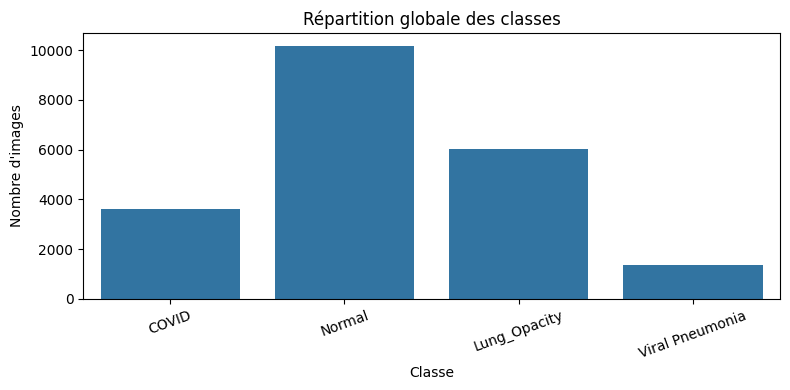

In [12]:

# =========================
# Répartition globale des classes
# =========================
class_counts = pd.Series(y).value_counts().sort_index()
class_distribution_df = pd.DataFrame({
    "class_id": range(NUM_CLASSES),
    "class_name": CATEGORIES,
    "count": class_counts.values
})

display(class_distribution_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=class_distribution_df, x="class_name", y="count")
plt.title("Répartition globale des classes")
plt.xlabel("Classe")
plt.ylabel("Nombre d'images")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [13]:

# =========================
# Split train / validation / test
# =========================
# On garde la logique suivante :
# - 20% test final
# - puis 20% du train restant pour validation
# Cela donne environ :
# - 64% train
# - 16% validation
# - 20% test

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.20,
    stratify=y_trainval,
    random_state=SEED
)

print("Train :", X_train.shape, y_train.shape)
print("Val   :", X_val.shape, y_val.shape)
print("Test  :", X_test.shape, y_test.shape)

Train : (13545, 128, 128, 1) (13545,)
Val   : (3387, 128, 128, 1) (3387,)
Test  : (4233, 128, 128, 1) (4233,)


,split,class_id,class_name,count
0,train,0,COVID,2314
1,train,1,Normal,6523
2,train,2,Lung_Opacity,3847
3,train,3,Viral Pneumonia,861
4,val,0,COVID,579
5,val,1,Normal,1631
6,val,2,Lung_Opacity,962
7,val,3,Viral Pneumonia,215
8,test,0,COVID,723
9,test,1,Normal,2038


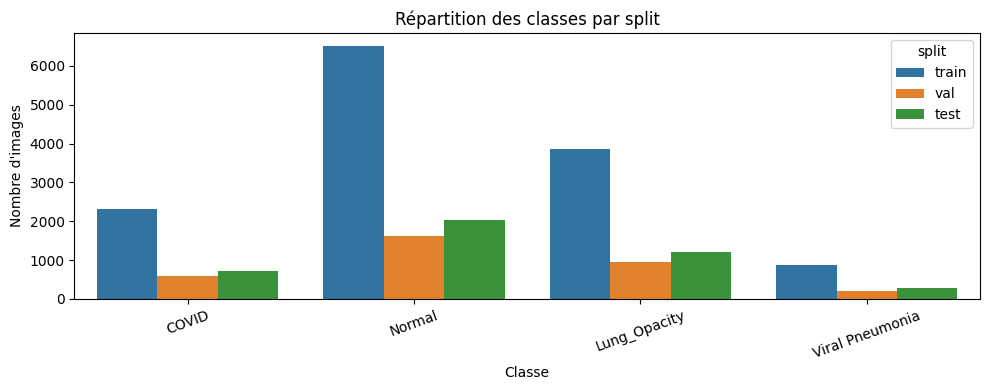

In [14]:

# =========================
# Répartition des classes après split
# =========================
def make_split_distribution(name, y_split):
    counts = pd.Series(y_split).value_counts().sort_index()
    return pd.DataFrame({
        "split": name,
        "class_id": range(NUM_CLASSES),
        "class_name": CATEGORIES,
        "count": counts.values
    })

split_dist_df = pd.concat([
    make_split_distribution("train", y_train),
    make_split_distribution("val", y_val),
    make_split_distribution("test", y_test),
], axis=0, ignore_index=True)

display(split_dist_df.head(12))

plt.figure(figsize=(10, 4))
sns.barplot(data=split_dist_df, x="class_name", y="count", hue="split")
plt.title("Répartition des classes par split")
plt.xlabel("Classe")
plt.ylabel("Nombre d'images")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [15]:

# =========================
# Class weights
# =========================
# Le dataset est déséquilibré.
# On calcule des poids de classes à partir du TRAIN uniquement.
# Cela permettra au modèle Dense de ne pas être trop dominé par les classes majoritaires.

classes = np.unique(y_train)
class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = {int(c): float(w) for c, w in zip(classes, class_weights_values)}
print("Class weights :", class_weight_dict)

Class weights : {0: 1.4633751080380293, 1: 0.5191246359037253, 2: 0.8802313491031973, 3: 3.932926829268293}


In [16]:

# =========================
# Pipelines tf.data
# =========================
# Ici, les images sont déjà prétraitées et en mémoire.
# On crée simplement des datasets TensorFlow pour rendre l'entraînement plus fluide.

AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(buffer_size=len(X_train), seed=SEED, reshuffle_each_iteration=True)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("Datasets tf.data prêts.")

Datasets tf.data prêts.


## Pourquoi un modèle Dense aussi simple ?

Parce que c'est un **baseline témoin**.

Ici, on veut éviter :
- un modèle trop gros
- un modèle trop compliqué
- un baseline qui surapprend immédiatement

Le but est d'obtenir une référence :
- facile à entraîner
- facile à lire
- facile à comparer aux futurs CNN

In [17]:

# =========================
# Définition du modèle Dense baseline
# =========================
# Architecture choisie :
# Input -> Flatten -> Dense(256) -> Dropout -> Dense(64) -> Dropout -> Softmax
#
# Pourquoi ce choix ?
# - suffisamment simple pour être un "modèle témoin"
# - suffisamment non trivial pour apprendre autre chose qu'une séparation minimale
# - régularisation légère avec Dropout + L2

def build_dense_baseline(input_shape=(TARGET_SIZE, TARGET_SIZE, N_CHANNELS), num_classes=NUM_CLASSES):
    inputs = keras.Input(shape=input_shape, name="input_image")

    x = layers.Flatten(name="flatten")(inputs)

    x = layers.Dense(
        DENSE_UNITS_1,
        activation="relu",
        kernel_regularizer=regularizers.l2(L2_REG),
        name="dense_1"
    )(x)
    x = layers.Dropout(DROPOUT_1, name="dropout_1")(x)

    x = layers.Dense(
        DENSE_UNITS_2,
        activation="relu",
        kernel_regularizer=regularizers.l2(L2_REG),
        name="dense_2"
    )(x)
    x = layers.Dropout(DROPOUT_2, name="dropout_2")(x)

    outputs = layers.Dense(num_classes, activation="softmax", name="classifier")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="dense_baseline")
    return model

model = build_dense_baseline()
model.summary()

Model: "dense_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,211,268 (16.06 MB)

 Trainable params: 4,211,268 (16.06 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:

# =========================
# Compilation du modèle
# =========================
# - sparse_categorical_crossentropy : car y contient des entiers 0,1,2,3
# - accuracy : simple et lisible
# - Adam : bon optimiseur de départ pour ce type de baseline

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [19]:

# =========================
# Callbacks
# =========================
# EarlyStopping :
# - arrête si la validation ne s'améliore plus
# - recharge les meilleurs poids
#
# ReduceLROnPlateau :
# - réduit le learning rate si la validation stagne
#
# ModelCheckpoint :
# - sauvegarde automatiquement le meilleur modèle

checkpoint_path = "best_dense_baseline.keras"

callbacks_list = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [20]:

# =========================
# Entraînement
# =========================
# On utilise class_weight pour compenser le déséquilibre des classes.
# Cela est particulièrement utile pour la classe COVID si elle reste plus difficile.

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks_list,
    verbose=1
)

Epoch 1/25
424/424 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4012 - loss: 1.4386
Epoch 1: val_loss improved from None to 1.08550, saving model to best_dense_baseline.keras

Epoch 1: finished saving model to best_dense_baseline.keras
424/424 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.4363 - loss: 1.2081 - val_accuracy: 0.5911 - val_loss: 1.0855 - learning_rate: 0.0010
Epoch 2/25
417/424 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4942 - loss: 1.0401
Epoch 2: val_loss improved from 1.08550 to 1.06921, saving model to best_dense_baseline.keras

Epoch 2: finished saving model to best_dense_baseline.keras
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4972 - loss: 1.0200 - val_accuracy: 0.5592 - val_loss: 1.0692 - learning_rate: 0.0010
Epoch 3/25
418/424 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5354 - loss: 0.9764
Epoch 3: val_loss improved from 1.06921 to 1.01719, saving model to best_dense_baseline.keras

Epoch 3: finished saving model to best_dense_baseline.ke

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.436323,1.208069,0.591084,1.085504,0.001
1,0.497231,1.020041,0.559197,1.069209,0.001
2,0.540347,0.977401,0.614408,1.017190,0.001
3,0.551643,0.952343,0.601712,1.042288,0.001
4,0.565079,0.916737,0.625923,0.989161,0.001


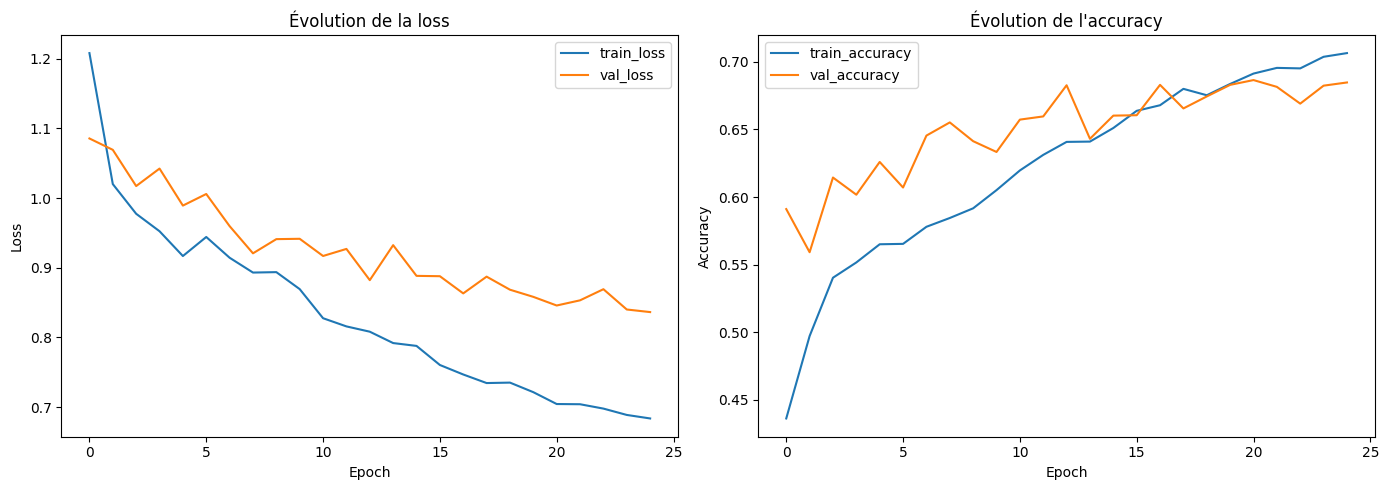

In [21]:

# =========================
# Courbes d'apprentissage
# =========================
# On trace :
# - loss train / val
# - accuracy train / val
#
# Ces courbes seront très utiles pour comparer ce baseline Dense
# aux futurs CNN et aux modèles de transfert learning.

history_df = pd.DataFrame(history.history)
display(history_df.head())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history["loss"], label="train_loss")
axes[0].plot(history.history["val_loss"], label="val_loss")
axes[0].set_title("Évolution de la loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Accuracy
axes[1].plot(history.history["accuracy"], label="train_accuracy")
axes[1].plot(history.history["val_accuracy"], label="val_accuracy")
axes[1].set_title("Évolution de l'accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

In [22]:

# =========================
# Évaluation sur le jeu de test
# =========================
# On évalue le meilleur modèle final sur le test.
# C'est cette section qui servira de comparaison avec les notebooks suivants.

test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_acc:.4f}")

# Prédictions
y_proba = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_proba, axis=1)

# Rapport de classification
report = classification_report(
    y_test,
    y_pred,
    target_names=CATEGORIES,
    digits=4,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
display(report_df)

print("\nClassification report (texte) :\n")
print(classification_report(y_test, y_pred, target_names=CATEGORIES, digits=4))

133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6877 - loss: 0.8426
Test loss     : 0.8426
Test accuracy : 0.6877
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


,precision,recall,f1-score,support
COVID,0.435754,0.431535,0.433634,723.000000
Normal,0.809649,0.757605,0.782763,2038.000000
Lung_Opacity,0.630852,0.683292,0.656026,1203.000000
Viral Pneumonia,0.758958,0.866171,0.809028,269.000000
accuracy,0.687692,0.687692,0.687692,0.687692
macro avg,0.658803,0.684651,0.670363,4233.000000
weighted avg,0.691753,0.687692,0.688782,4233.000000



Classification report (texte) :

                 precision    recall  f1-score   support

          COVID     0.4358    0.4315    0.4336       723
         Normal     0.8096    0.7576    0.7828      2038
   Lung_Opacity     0.6309    0.6833    0.6560      1203
Viral Pneumonia     0.7590    0.8662    0.8090       269

       accuracy                         0.6877      4233
      macro avg     0.6588    0.6847    0.6704      4233
   weighted avg     0.6918    0.6877    0.6888      4233



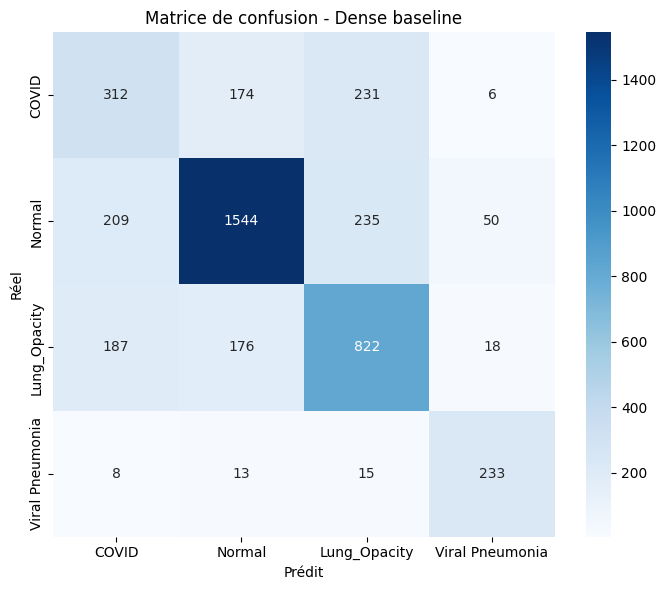

In [23]:

# =========================
# Matrice de confusion
# =========================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CATEGORIES,
    yticklabels=CATEGORIES
)
plt.title("Matrice de confusion - Dense baseline")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.tight_layout()
plt.show()

In [24]:

# =========================
# Tableau de métriques par classe
# =========================
# On construit un tableau plus lisible centré sur les classes.
# Cela aide beaucoup pour suivre particulièrement la classe COVID.

per_class_df = report_df.loc[CATEGORIES, ["precision", "recall", "f1-score", "support"]].copy()
per_class_df = per_class_df.reset_index().rename(columns={"index": "class_name"})
display(per_class_df)

,class_name,precision,recall,f1-score,support
0,COVID,0.435754,0.431535,0.433634,723.0
1,Normal,0.809649,0.757605,0.782763,2038.0
2,Lung_Opacity,0.630852,0.683292,0.656026,1203.0
3,Viral Pneumonia,0.758958,0.866171,0.809028,269.0


## Lecture rapide des résultats


1. **val_loss / val_accuracy** : **le modèle apprend-il proprement ?** 

oui, globalement le modèle apprend correctement, même si l’apprentissage n’est pas parfaitement régulier. Le modèle converge de manière satisfaisante pour un modèle Dense de référence, même si les métriques de validation restent fluctuantes.

2. **écart train vs validation** : y a-t-il surapprentissage ?

il existe au maximum un surapprentissage léger et maîtrisé, mais pas de divergence nette entre les performances d’entraînement et de validation.

3. **recall COVID** : reste-t-il faible ?

Le COVID possède clairement le rappel le plus faible. Le modèle Dense reste nettement insuffisant pour reconnaître correctement la classe COVID.

4. **confusion COVID vs Lung_Opacity** : est-ce une confusion dominante ?

oui, la confusion entre COVID et Lung_Opacity est dominante, particulièrement pour les radiographies réellement COVID. Toutefois, la confusion entre Normal et Lung_Opacity est presque aussi importante.

## Conclusion 

Les courbes montrent que le modèle Dense apprend de manière globalement stable : la loss d’entraînement diminue de 1,2081 à 0,6836, tandis que la validation loss atteint 0,8363. L’écart final entre les accuracies d’entraînement et de validation reste limité à environ 2,2 points, ce qui indique l’absence de surapprentissage sévère, même si les oscillations de la validation loss suggèrent un léger début de surapprentissage. 

Sur le jeu de test, le modèle atteint une accuracy de 68,77 %. La principale faiblesse concerne la classe COVID, dont le recall n’est que de 43,15 % : seulement 312 des 723 images COVID sont correctement détectées. 

La confusion dominante concerne les classes COVID et Lung_Opacity, avec 231 images COVID prédites comme Lung_Opacity et 187 images Lung_Opacity prédites comme COVID. Ces résultats confirment les limites attendues d’un réseau Dense appliqué à des images aplaties. Le modèle ne préserve pas explicitement les relations spatiales et les motifs locaux présents dans les radiographies. 

Il constitue néanmoins **un modèle témoin** pertinent pour mesurer les améliorations apportées par le futur CNN.

## Étape suivante
Le prochain notebook sera naturellement :

### CNN custom TensorFlow / Keras
et il pourra réutiliser en grande partie :
- le téléchargement du dataset
- les mêmes fonctions de prétraitement
- le même split train / val / test
- le même style d'évaluation

Autrement dit : **ce notebook pose la base commune de la suite**.